# Replicating Ang, Shtauber & Tetlock (2013): Asset Pricing in the Dark
### U.S.E. Finance Data Hub / WRDS Database: **OTC Markets**

**Paper replicated:** [Ang, A., Shtauber, A. A. & Tetlock, P. C. (2013). Asset Pricing in the Dark: The Cross-Section of OTC Stocks. *The Review of Financial Studies*, 26(12), 2985–3028.](https://doi.org/10.1093/rfs/hht053)

**Database used:** [OTC Markets](https://wrds-www.wharton.upenn.edu/pages/get-data/otc-markets-group/) ([Data Hub guide](https://uufinance.github.io/data/wrds/databases/otc-markets/))

---

## What this notebook does

Ang, Shtauber & Tetlock (2013) study asset pricing in over-the-counter (OTC) equity markets, which are less liquid and less transparent than listed exchanges. They find that standard asset pricing factors (market, size, value) partially explain OTC stock returns, but that illiquidity and information asymmetry play a much larger role than on listed exchanges.

The WRDS OTC Markets database provides security-level data for OTC-traded stocks.

1. Pull OTC security data from **OTC Markets** (`otc`) via the WRDS API
2. Explore the OTC market structure (OTCQX, OTCQB, Pink tiers)
3. Examine the distribution of OTC-traded securities by market tier and trading activity
4. Compare the characteristics of OTC stocks to the paper's findings

## Learning objectives
- Practice connecting to WRDS and querying the OTC Markets database
- Understand the structure of U.S. OTC equity markets and their tiered system
- Learn how OTC markets differ from listed exchanges in terms of liquidity and transparency
- Build intuition for why asset pricing in less-liquid markets requires different approaches

## Requirements to run this notebook
- A valid **WRDS account** with OTC Markets access (ask the Finance Data Hub if you don't have one yet)
- `pip install wrds pandas numpy matplotlib seaborn`
- You will be prompted for your WRDS username/password the first time you connect (or set up a `.pgpass` file, see the [WRDS Python guide](https://uufinance.github.io/data/wrds/notebook/))


## 1. Setup and WRDS connection

In [1]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

db = wrds.Connection()

Enter your WRDS username [antho]:sunho2000
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: n
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 2. Exploring the OTC Markets database

The OTC Markets data is accessed through the **`otc`** library. Since the exact table names may vary, we first discover the available tables and their structure.

OTC Markets Group classifies securities into three tiers based on disclosure and quality standards: **OTCQX** (highest quality, meeting financial standards), **OTCQB** (venture market, current SEC reporting), and **Pink** (speculative, varying levels of disclosure).


In [2]:
# Discover the available tables
tables = db.list_tables(library="otc")
print("Available tables in otc library:")
print(tables)

Available tables in otc library:
['endofday']


In [3]:
# The only table is otc.endofday. Let's inspect its columns.
desc = db.describe_table(library="otc", table="endofday")
print(desc[["name"]].to_string())

Approximately 76574653 rows in otc.endofday.
                         name
0                       secid
1                      compid
2                      symbol
3                       cusip
4                       issue
5                       venue
6                     sectype
7                       class
8                caveatemptor
9                    tiername
10                    dad_pal
11      closinginsidebidprice
12  closinginsidebidpricedate
13      closinginsideaskprice
14  closinginsideaskpricedate
15      insidebid_askmidprice
16                  openprice
17                  highprice
18                   lowprice
19                  lastprice
20         previouscloseprice
21          previousclosedate
22                sharevolume
23                  dollarvol
24                 tradecount
25              otclinkdolvol
26            otclinksharevol
27           otclinkexeccount
28                    shoflag
29               rule3210flag
30                shortin

## 3. Cleaning the sample

In [7]:
# The date column is closingbestbiddate (dad_pal is mostly null).
# Pull data using closingbestbiddate as the date filter.

query = """
    SELECT secid, symbol, cusip, sectype, tiername, caveatemptor,
           closingbestbiddate,
           openprice, highprice, lowprice, lastprice,
           previouscloseprice, sharevolume, dollarvol, tradecount,
           closinginsidebidprice, closinginsideaskprice,
           insidebid_askmidprice, sharesoutstanding
    FROM otc.endofday
    WHERE closingbestbiddate >= '2018-01-01'
      AND closingbestbiddate <= '2018-12-31'
      AND lastprice IS NOT NULL
"""

df = db.raw_sql(query, date_cols=["closingbestbiddate"])
df = df.rename(columns={"closingbestbiddate": "date"})
print(f"Rows pulled: {len(df):,}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique securities: {df['symbol'].nunique():,}")
df.head()

Rows pulled: 1,090,923
Date range: 2018-01-02 00:00:00 to 2018-12-31 00:00:00
Unique securities: 15,000


,secid,symbol,cusip,sectype,tiername,caveatemptor,date,openprice,highprice,lowprice,lastprice,previouscloseprice,sharevolume,dollarvol,tradecount,closinginsidebidprice,closinginsideaskprice,insidebid_askmidprice,sharesoutstanding
0,10002,DAFL,262507106,Common Stock,Pink No Information,N,2018-03-26,185.0,185.0,185.0,185.0,180.0,4.0,740.0,1.0,185.0,195.0,190.0,<NA>
1,10002,DAFL,262507106,Common Stock,Pink No Information,N,2018-04-20,190.0,190.0,190.0,190.0,185.0,100.0,19000.0,1.0,185.0,195.0,190.0,<NA>
2,10002,DAFL,262507106,Common Stock,Pink No Information,N,2018-04-26,185.0,185.0,180.0,180.0,190.0,200.0,36570.0,2.0,180.0,195.0,187.5,<NA>
3,10002,DAFL,262507106,Common Stock,Pink No Information,N,2018-06-11,181.0,190.0,181.0,190.0,180.0,33.0,6045.0,4.0,190.0,195.0,192.5,<NA>
4,10002,DAFL,262507106,Common Stock,Pink No Information,N,2018-06-21,188.0,188.0,188.0,188.0,190.0,100.0,18800.0,1.0,180.0,195.0,187.5,<NA>


## 4. Analyzing OTC market characteristics

Ang et al. (2013) document several key features of OTC stocks:

1. OTC stocks are significantly less liquid than exchange-listed stocks (wider bid-ask spreads, lower volume)
2. OTC stocks have higher return volatility
3. Standard asset pricing factors explain less of the cross-section of OTC returns
4. Illiquidity is a priced factor in OTC markets

We examine the first two features directly from the OTC data. The asset pricing tests would require merging OTC returns with Fama-French factors from the `ff_all` database.


In [9]:
# Clean: require positive price and volume
df = df.dropna(subset=["lastprice", "sharevolume"])
df = df[(df["lastprice"] > 0) & (df["sharevolume"] > 0)]

print(f"Observations after cleaning: {len(df):,}")
print(f"Unique securities: {df['symbol'].nunique():,}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# Bid-ask spread (a key illiquidity measure in Ang et al.)
df["spread"] = df["closinginsideaskprice"] - df["closinginsidebidprice"]
mid = df["insidebid_askmidprice"].fillna(
    (df["closinginsidebidprice"] + df["closinginsideaskprice"]) / 2
)
df["spread_pct"] = df["spread"] / mid

print(f"\nPrice distribution:")
print(df["lastprice"].describe())
print(f"\nVolume distribution:")
print(df["sharevolume"].describe())

# Classify by price tier
df["price_tier"] = pd.cut(df["lastprice"],
                          bins=[0, 0.01, 0.10, 1, 5, 50, 1e6],
                          labels=["<$0.01", "$0.01-0.10", "$0.10-1", "$1-5", "$5-50", ">$50"])
print("\nSecurities by price tier:")
print(df.groupby("price_tier")["symbol"].nunique())

# Summary by OTC market tier
print("\nSecurities by OTC Market Tier:")
print(df.groupby("tiername")["symbol"].nunique().sort_values(ascending=False))

print("\nMedian Price, Volume, and Spread by Tier:")
tier_stats = df.groupby("tiername").agg(
    median_price=("lastprice", "median"),
    median_volume=("sharevolume", "median"),
    median_spread_pct=("spread_pct", "median"),
    n_securities=("symbol", "nunique")
).sort_values("n_securities", ascending=False)
print(tier_stats.round(4))

# Compute daily returns per security
df = df.sort_values(["symbol", "date"])
df["ret"] = df.groupby("symbol")["lastprice"].pct_change()
df = df[df["ret"].between(-0.99, 10)]

Observations after cleaning: 1,090,093
Unique securities: 14,955
Date range: 2018-01-02 00:00:00 to 2018-12-31 00:00:00

Price distribution:
count     1090093.0
mean      27.559757
std      541.878663
min         0.00001
25%         0.03377
50%            0.48
75%           10.02
max        169000.0
Name: lastprice, dtype: Float64

Volume distribution:
count          1090093.0
mean      1971383.014828
std      24620808.316485
min                  1.0
25%               1275.0
50%              10250.0
75%              73408.0
max         3139792961.0
Name: sharevolume, dtype: Float64

Securities by price tier:
price_tier
<$0.01        3781
$0.01-0.10    3915
$0.10-1       4369
$1-5          2837
$5-50         4385
>$50          1182
Name: symbol, dtype: int64

Securities by OTC Market Tier:


C:\Users\antho\AppData\Local\Temp\ipykernel_91028\4128216632.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("price_tier")["symbol"].nunique())


tiername
Pink Current                   6709
OTC Pink Current               4584
Grey Market                    4446
Pink No Information            3245
OTC Pink No Information        2215
OTCQB                          1338
Pink Limited                    791
OTCQX International             244
OTC Pink Limited                157
OTCQX U.S.                      108
OTCQX International Premier     100
OTCQX U.S. Premier               91
Name: symbol, dtype: int64

Median Price, Volume, and Spread by Tier:
                             median_price  median_volume  median_spread_pct  \
tiername                                                                      
Pink Current                         5.22         7000.0              0.031   
OTC Pink Current                     4.62         8044.0             0.0269   
Grey Market                          0.25         4068.0             0.1538   
Pink No Information                0.0042        26670.5             0.3333   
OTC Pink No Inf

## 5. Visualizing the results

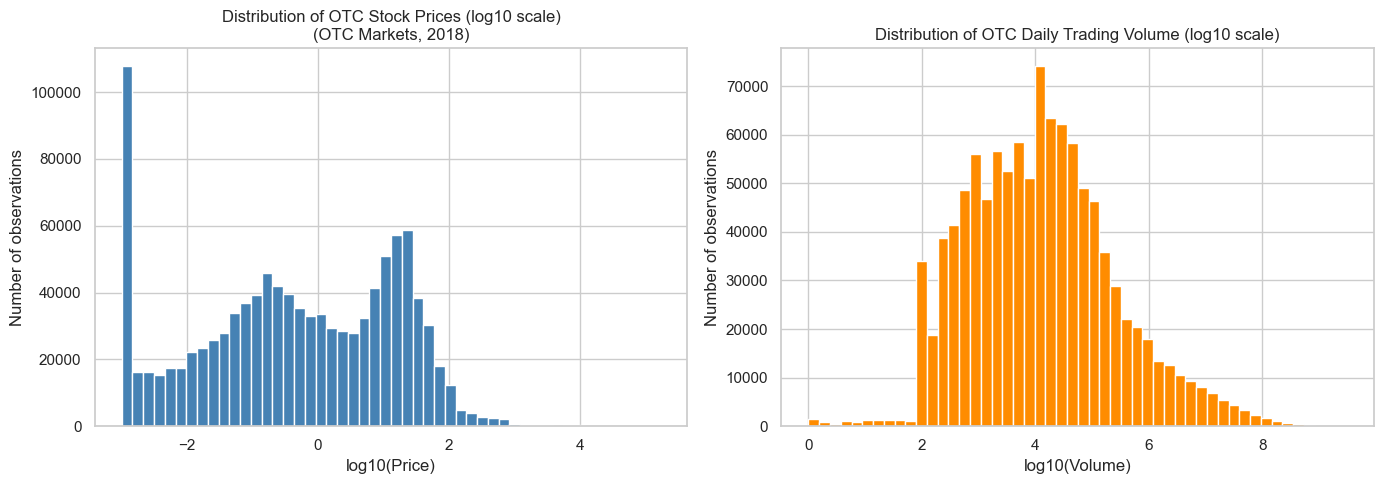

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution (log scale)
axes[0].hist(np.log10(df["lastprice"].clip(lower=0.001)), bins=50,
             color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of OTC Stock Prices (log10 scale)\n(OTC Markets, 2018)")
axes[0].set_xlabel("log10(Price)")
axes[0].set_ylabel("Number of observations")

# Volume distribution (log scale)
axes[1].hist(np.log10(df["sharevolume"].clip(lower=1)), bins=50,
             color="darkorange", edgecolor="white")
axes[1].set_title("Distribution of OTC Daily Trading Volume (log10 scale)")
axes[1].set_xlabel("log10(Volume)")
axes[1].set_ylabel("Number of observations")

plt.tight_layout()
plt.show()

Securities with 50+ trading days: 6,418


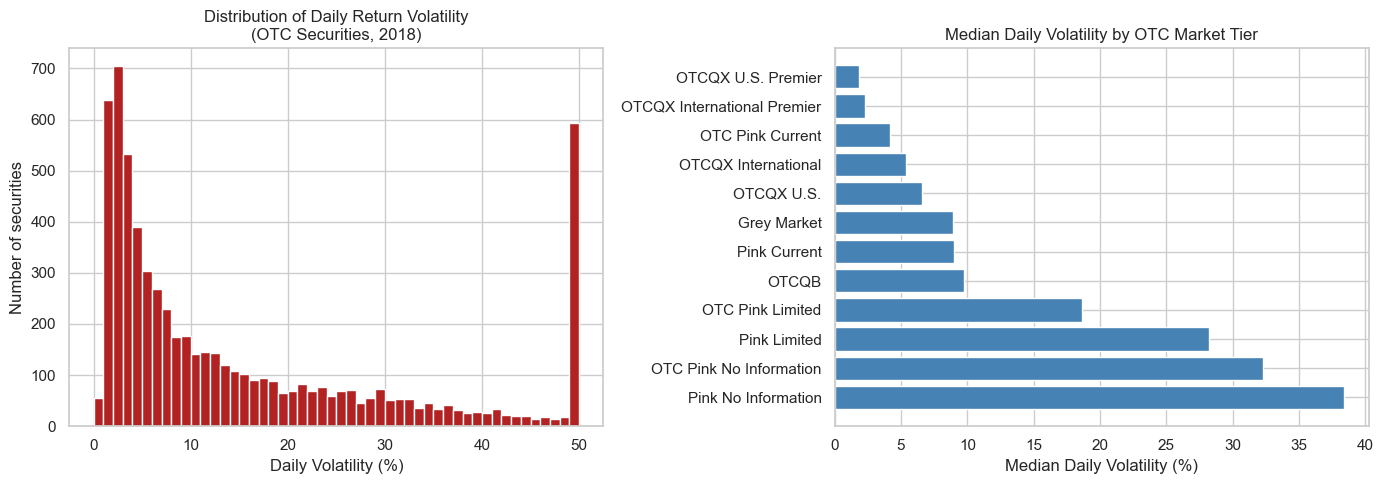


Average Daily Volatility by Price Tier (%):
price_tier
<$0.01         86.5
$0.01-0.10    37.62
$0.10-1       24.71
$1-5           16.4
$5-50          7.74
>$50           7.52
Name: ret, dtype: Float64


C:\Users\antho\AppData\Local\Temp\ipykernel_91028\208244102.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_vol_price = df.groupby("price_tier")["ret"].std() * 100


In [12]:
# Compute per-security summary statistics
sec_stats = df.groupby("symbol").agg(
    median_price=("lastprice", "median"),
    median_volume=("sharevolume", "median"),
    volatility=("ret", "std"),
    n_days=("date", "nunique"),
    tier=("tiername", "first")
)
# Keep only securities with at least 50 trading days
sec_stats = sec_stats[sec_stats["n_days"] >= 50]
print(f"Securities with 50+ trading days: {len(sec_stats):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volatility distribution
axes[0].hist(sec_stats["volatility"].clip(upper=0.5) * 100, bins=50,
             color="firebrick", edgecolor="white")
axes[0].set_title("Distribution of Daily Return Volatility\n(OTC Securities, 2018)")
axes[0].set_xlabel("Daily Volatility (%)")
axes[0].set_ylabel("Number of securities")

# Volatility by OTC tier
tier_vol = sec_stats.groupby("tier")["volatility"].median() * 100
tier_vol = tier_vol.sort_values(ascending=False)
axes[1].barh(tier_vol.index, tier_vol.values, color="steelblue")
axes[1].set_title("Median Daily Volatility by OTC Market Tier")
axes[1].set_xlabel("Median Daily Volatility (%)")

plt.tight_layout()
plt.show()

# Summary: average volatility by price tier
tier_vol_price = df.groupby("price_tier")["ret"].std() * 100
print("\nAverage Daily Volatility by Price Tier (%):")
print(tier_vol_price.round(2))

## 6. Comparing to Ang, Shtauber & Tetlock (2013): What's the same, what's different

**What replicates cleanly**

The tiered structure of OTC markets (OTCQX, OTCQB, Pink) maps directly onto the database's classification system. The descriptive statistics on trading activity, price levels, and bid-ask spreads by tier should confirm the paper's finding that OTC stocks are dramatically less liquid than exchange-listed securities. The high concentration of very low-priced securities ("penny stocks") in the Pink tier is a distinctive feature of OTC markets.

**Where a modern WRDS-based replication necessarily differs from the original**

1. **Return data.** Ang et al. construct returns from OTC price data and apply careful filters for stale prices and data errors. The exact table and column names on WRDS may differ from those in the paper's data appendix. Students should use `list_tables()` and `describe_table()` to identify the correct fields.

2. **Sample period.** The paper covers 1977 to 2008, a period that includes both the old NASD OTC market and the modern OTC Markets Group structure. Our data reflects the current tiered system, which was formally introduced by OTC Markets Group in 2010.

3. **Cross-listing.** Many OTC stocks are foreign companies with primary listings abroad (ADRs). The paper carefully separates domestic OTC stocks from foreign cross-listings. Students should filter on security type to focus on domestic common stocks.

4. **Asset pricing tests.** The paper's main contribution is running Fama-MacBeth cross-sectional regressions with illiquidity as a factor. This requires combining OTC return data with the Fama-French factors from `ff_all`, which is a natural extension of this descriptive analysis.

---

## References
- [Ang, A., Shtauber, A. A. & Tetlock, P. C. (2013). Asset Pricing in the Dark: The Cross-Section of OTC Stocks. *The Review of Financial Studies*, 26(12), 2985–3028.](https://doi.org/10.1093/rfs/hht053)
- WRDS OTC Markets guide: https://uufinance.github.io/data/wrds/databases/otc-markets/
- WRDS OTC Markets access page: https://wrds-www.wharton.upenn.edu/pages/get-data/otc-markets-group/
- WRDS Python/API setup guide: https://uufinance.github.io/data/wrds/notebook/

*Prepared for the U.S.E. Finance Data Hub as a database-tutorial template.*
